<a href="https://colab.research.google.com/github/RonakMaini/pneumonia-detection-cnn-swin/blob/main/mutliscalecnn%2Bswintransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 : Setup

# Install required libraries
!pip install -q torch torchvision timm scikit-learn

# Imports
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import timm

from PIL import Image

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Copy dataset from Google Drive to Colab SSD
!cp -r "/content/drive/MyDrive/dataset/Pneumonia_Project/Pediatric Chest X-ray Pneumonia" "/content/"

dataset_path = "/content/Pediatric Chest X-ray Pneumonia"

print("====================================")
print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device :", device)

print("Dataset Exists :", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Folders :", os.listdir(dataset_path))

print("====================================")

PyTorch Version : 2.11.0+cu128
CUDA Available : True
Using Device : cuda
Dataset Exists : True
Folders : ['train', 'test']


In [ ]:
# CELL 2 : Data Preprocessing & DataLoaders

import numpy as np
import random
from torch.utils.data import WeightedRandomSampler

# Full seeding for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Training Transforms — stronger, more varied augmentation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Validation & Test Transforms
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Load Dataset
train_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_path, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_path, "test"),
    transform=test_transform
)

# Split Training & Validation (seeded for reproducibility)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# WeightedRandomSampler: oversample NORMAL so each
# training batch sees roughly equal class exposure
train_targets = np.array(train_dataset.targets)[train_data.indices]

class_sample_counts = np.array([
    (train_targets == 0).sum(),
    (train_targets == 1).sum()
])

sample_weights = 1.0 / class_sample_counts[train_targets]
sample_weights = torch.from_numpy(sample_weights).double()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
batch_size = 32

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("="*50)
print("Training Images   :", len(train_data))
print("Validation Images :", len(val_data))
print("Test Images       :", len(test_dataset))
print("Classes           :", train_dataset.classes)
print("NORMAL count (train)   :", class_sample_counts[0])
print("PNEUMONIA count (train):", class_sample_counts[1])
print("="*50)

Training Images   : 4185
Validation Images : 1047
Test Images       : 624
Classes           : ['NORMAL', 'PNEUMONIA']
NORMAL count (train)   : 1079
PNEUMONIA count (train): 3106


In [ ]:
# CELL 3 : Improved Hybrid CNN + Swin Transformer


class HybridMultiScaleSwin(nn.Module):

    def __init__(self):
        super().__init__()

        # -------- Multi-Scale CNN --------

        self.branch3 = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.branch5 = nn.Sequential(
            nn.Conv2d(3,32,5,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.branch7 = nn.Sequential(
            nn.Conv2d(3,32,7,padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.cnn_block = nn.Sequential(

            nn.Conv2d(96,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        # -------- Swin Transformer --------

        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        # -------- Feature Fusion --------

        self.classifier = nn.Sequential(

            nn.Linear(256+768,512),

            nn.BatchNorm1d(512),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(512,128),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(128,2)

        )

    def forward(self,x):

        b1 = self.branch3(x)

        b2 = self.branch5(x)

        b3 = self.branch7(x)

        cnn = torch.cat([b1,b2,b3],dim=1)

        cnn = self.cnn_block(cnn)

        cnn = cnn.view(cnn.size(0),-1)

        swin = self.swin(x)

        fusion = torch.cat([cnn,swin],dim=1)

        output = self.classifier(fusion)

        return output


print("="*50)
print(" Improved Hybrid CNN + Swin Ready")
print("="*50)

 Improved Hybrid CNN + Swin Ready


In [ ]:
# CELL 4 : Model + Loss + Optimizer + Scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridMultiScaleSwin().to(device)

for param in model.swin.parameters():
    param.requires_grad = False

print("✅ Swin Backbone Frozen")

# Label smoothing helps generalization / reduces overconfidence,
# on top of the sampler balancing class exposure
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("="*50)
print("Device :", device)
print("Loss Function : CrossEntropyLoss (label_smoothing=0.05, sampler balances classes)")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")
print("="*50)

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

✅ Swin Backbone Frozen
Device : cuda
Loss Function : CrossEntropyLoss (label_smoothing=0.05, sampler balances classes)
Optimizer : AdamW
Scheduler : ReduceLROnPlateau


In [ ]:
# CELL 5 : Training & Validation Functions

from sklearn.metrics import accuracy_score, f1_score


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(loader)
    train_acc = 100 * correct / total
    return train_loss, train_acc


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader)
    val_acc = 100 * accuracy_score(all_labels, all_preds)
    val_f1 = 100 * f1_score(all_labels, all_preds, average="macro")

    return val_loss, val_acc, val_f1


print("="*50)
print("✅ Training Function Ready")
print("✅ Validation Function Ready (tracks macro-F1)")
print("="*50)

✅ Training Function Ready
✅ Validation Function Ready (tracks macro-F1)


In [ ]:
# CELL 6 : Training Hybrid Model

epochs = 20

best_val_f1 = 0
patience = 6
counter = 0

for epoch in range(epochs):

    if epoch == 5:
        print("\n🔓 Unfreezing Swin Transformer...\n")
        for param in model.swin.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=5e-5,
            weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=2
        )

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion)

    scheduler.step(val_f1)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
        f"Val Macro-F1: {val_f1:.2f}%"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/dataset/Pneumonia_Project/hybrid_multiscale_swin_best.pth"
        )
        print("✅ Best Model Saved (by Macro-F1)")
    else:
        counter += 1

    if counter >= patience:
        print("\n🛑 Early Stopping Triggered")
        break

print("\n====================================")
print("Training Finished")
print("Best Validation Macro-F1 :", round(best_val_f1,2), "%")
print("====================================")

Epoch [1/20] | Train Loss: 0.3183 | Train Acc: 89.68% | Val Loss: 0.2747 | Val Acc: 91.79% | Val Macro-F1: 90.05%
✅ Best Model Saved (by Macro-F1)
Epoch [2/20] | Train Loss: 0.2711 | Train Acc: 92.76% | Val Loss: 0.2303 | Val Acc: 94.46% | Val Macro-F1: 93.01%
✅ Best Model Saved (by Macro-F1)
Epoch [3/20] | Train Loss: 0.2461 | Train Acc: 94.15% | Val Loss: 0.2264 | Val Acc: 94.46% | Val Macro-F1: 93.07%
✅ Best Model Saved (by Macro-F1)
Epoch [4/20] | Train Loss: 0.2323 | Train Acc: 94.89% | Val Loss: 0.2039 | Val Acc: 96.08% | Val Macro-F1: 94.99%
✅ Best Model Saved (by Macro-F1)
Epoch [5/20] | Train Loss: 0.2550 | Train Acc: 93.67% | Val Loss: 0.1975 | Val Acc: 96.85% | Val Macro-F1: 95.96%
✅ Best Model Saved (by Macro-F1)

🔓 Unfreezing Swin Transformer...

Epoch [6/20] | Train Loss: 0.2414 | Train Acc: 94.70% | Val Loss: 0.1994 | Val Acc: 96.47% | Val Macro-F1: 95.54%
Epoch [7/20] | Train Loss: 0.1916 | Train Acc: 96.89% | Val Loss: 0.2172 | Val Acc: 96.18% | Val Macro-F1: 94.79%
Ep

In [ ]:
# CELL 7 : Load Best Hybrid Model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridMultiScaleSwin().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/dataset/Pneumonia_Project/hybrid_multiscale_swin_best.pth",
        map_location=device
    )
)

model.eval()

print("="*50)
print("✅ Best Hybrid Model Loaded Successfully")
print("Using Device :", device)
print("="*50)

✅ Best Hybrid Model Loaded Successfully
Using Device : cuda


Saving person17_virus_48.jpeg to person17_virus_48.jpeg


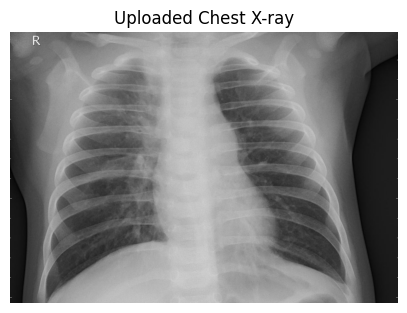

Prediction : PNEUMONIA
Confidence : 94.13 %


In [ ]:
# CELL 8 : Predict Chest X-ray


from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms

# Upload Image
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read Image
image = Image.open(file_name).convert("RGB")

# Show Image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Uploaded Chest X-ray")
plt.axis("off")
plt.show()

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

image_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = F.softmax(output, dim=1)

    confidence, prediction = torch.max(probabilities, 1)

classes = ["NORMAL", "PNEUMONIA"]

print("="*50)
print("Prediction :", classes[prediction.item()])
print("Confidence :", round(confidence.item()*100,2), "%")
print("="*50)

In [ ]:
# CELL 9 : Final Evaluation

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

model.eval()

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_scores.extend(probabilities[:, 1].cpu().numpy())

print("="*60)
print("TEST RESULTS")
print("="*60)

print(f"Accuracy : {accuracy_score(y_true,y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_true,y_pred,average='weighted')*100:.2f}%")
print(f"Recall   : {recall_score(y_true,y_pred,average='weighted')*100:.2f}%")
print(f"F1 Score : {f1_score(y_true,y_pred,average='weighted')*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL","PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix\n")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Hybrid Multi-Scale Swin")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300)
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0,1], [0,1], color="navy", lw=1, linestyle="--", label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Multi-Scale Swin")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/roc_curve.png", dpi=300)
plt.show()

print("="*60)
print(f"ROC-AUC Score : {auc_score:.4f}")
print("="*60)